In [228]:
import pandas as pd
import re
import copy
from collections import Counter

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [229]:
BATCH_SIZE = 64
EMBEDDING_DIM = 64
HIDDEN_SIZE = 128

LEARNING_RATE = 0.001
EPOCHS = 10
PATIENCE = 3

NUM_WORKERS = 4

In [230]:
df = pd.read_csv('../datasets/twitter_sentiment.csv')

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (74682, 4)


,Tweet ID,entity,sentiment,Tweet content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [231]:
data = df[["Tweet content", "sentiment"]].copy()

# Remove missing values
data.dropna(inplace=True)

# Make sure tweet content is text
data["Tweet content"] = data["Tweet content"].astype(str)

# Remove leading/trailing spaces from sentiment labels
data["sentiment"] = data["sentiment"].astype(str).str.strip()

print("\nSentiment classes:")
print(data["sentiment"].value_counts())



Sentiment classes:
sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


In [232]:
sentiment_classes = sorted(data["sentiment"].unique())

sentiment_map = {
    sentiment: index
    for index, sentiment in enumerate(sentiment_classes)
}

data["label"] = data["sentiment"].map(sentiment_map)

print("\nSentiment mapping:")
print(sentiment_map)


Sentiment mapping:
{'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


In [233]:
def tokenize(text):
    text = text.lower()

    # Extract words
    words = re.findall(r"\b\w+\b", text)

    return words


data["tokens"] = data["Tweet content"].apply(tokenize)

# Remove tweets that became empty after tokenization
data = data[data["tokens"].apply(len) > 0].copy()

print("\nData after cleaning:")
display(data.head())


Data after cleaning:


,Tweet content,sentiment,label,tokens
0,im getting on borderlands and i will murder yo...,Positive,3,"[im, getting, on, borderlands, and, i, will, m..."
1,I am coming to the borders and I will kill you...,Positive,3,"[i, am, coming, to, the, borders, and, i, will..."
2,im getting on borderlands and i will kill you ...,Positive,3,"[im, getting, on, borderlands, and, i, will, k..."
3,im coming on borderlands and i will murder you...,Positive,3,"[im, coming, on, borderlands, and, i, will, mu..."
4,im getting on borderlands 2 and i will murder ...,Positive,3,"[im, getting, on, borderlands, 2, and, i, will..."


In [234]:
texts = data["tokens"].tolist()
labels = data["label"].tolist()

In [235]:
# First split:
# 60% train
# 40% temporary

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.4,
    random_state=42,
    stratify=labels
)


# Split the remaining 40% into:
# 20% validation
# 20% test

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("\nDataset split:")
print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))



Dataset split:
Train: 44233
Validation: 14744
Test: 14745


In [236]:
word_counts = Counter()

for sentence in X_train_text:
    word_counts.update(sentence)


vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}


for word in word_counts:
    vocab[word] = len(vocab)


print("\nVocabulary size:", len(vocab))


Vocabulary size: 28195


In [237]:
def text_to_ids(texts, vocab):

    sequences = []

    for sentence in texts:

        ids = [
            vocab.get(word, vocab["<UNK>"])
            for word in sentence
        ]

        sequences.append(
            torch.tensor(ids, dtype=torch.long)
        )

    return sequences


X_train_sequences = text_to_ids(
    X_train_text,
    vocab
)

X_val_sequences = text_to_ids(
    X_val_text,
    vocab
)

X_test_sequences = text_to_ids(
    X_test_text,
    vocab
)

In [238]:
X_train = pad_sequence(
    X_train_sequences,
    batch_first=True,
    padding_value=vocab["<PAD>"]
)

X_val = pad_sequence(
    X_val_sequences,
    batch_first=True,
    padding_value=vocab["<PAD>"]
)

X_test = pad_sequence(
    X_test_sequences,
    batch_first=True,
    padding_value=vocab["<PAD>"]
)

# Convert labels into PyTorch tensors

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)


print("\nTensor shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)




Tensor shapes:
X_train: torch.Size([44233, 194])
X_val: torch.Size([14744, 198])
X_test: torch.Size([14745, 117])


###  12. CREATE DATASETS

In [239]:
train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

### 13. CREATE DATALOADERS

In [240]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

### 14. CREATE THE RNN MODEL

In [241]:
class SentimentRNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_size,
        num_classes
    ):

        super().__init__()


        self.padding_idx = vocab["<PAD>"]


        # Word ID -> Word vector
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=self.padding_idx
        )


        # Process the sequence
        self.rnn = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )


        # Final classification
        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )


    def forward(self, x):

        # Count real tokens before embedding, so padding does not decide the final state
        lengths = (x != self.padding_idx).sum(dim=1).clamp(min=1)


        # [batch, sequence]
        # ->
        # [batch, sequence, embedding_dim]
        x = self.embedding(x)


        # RNN processes every word
        output, hidden = self.rnn(x)


        # Take the output at the last real token, not at the padded end
        last_token_index = lengths - 1
        batch_index = torch.arange(
            output.size(0),
            device=output.device
        )
        x = output[batch_index, last_token_index]


        # Convert to class scores
        x = self.fc(x)


        return x


###  15. CREATE THE MODEL

In [242]:
print("CUDA available:", torch.cuda.is_available())
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
PyTorch version: 2.7.1+cu128
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [243]:
num_classes = len(sentiment_classes)

model = SentimentRNN(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_classes=num_classes
)

print("\nModel:")
print(model)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(device)


Model:
SentimentRNN(
  (embedding): Embedding(28195, 64, padding_idx=0)
  (rnn): GRU(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)
cuda


### 16. LOSS FUNCTION AND OPTIMIZER

In [244]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

### 17. TRAINING + VALIDATION + EARLY STOPPING

In [245]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0


for epoch in range(EPOCHS):

    # ---------------- TRAINING ----------------
    model.train()
    epoch_train_loss = 0

    for xb, yb in train_loader:

        # Move batch to the same device as the model
        xb = xb.to(device)
        yb = yb.to(device)

        # Forward pass
        preds = model(xb)

        # Calculate loss
        loss = loss_fn(preds, yb)

        # Clear old gradients
        optimizer.zero_grad()

        # Calculate gradients
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_train_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)


    # ---------------- VALIDATION ----------------
    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            # Move validation batch to GPU too
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)

            loss = loss_fn(preds, yb)

            epoch_val_loss += loss.item()

    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)


    print(
        f"Epoch: {epoch + 1:02d} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )


    # ---------------- EARLY STOPPING ----------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        patience_counter = 0

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:
            print("\nEarly stopping!")
            break

Epoch: 01 | Train Loss: 1.1892 | Val Loss: 1.0514
Epoch: 02 | Train Loss: 0.8754 | Val Loss: 0.8546
Epoch: 03 | Train Loss: 0.6071 | Val Loss: 0.6652
Epoch: 04 | Train Loss: 0.3935 | Val Loss: 0.5900
Epoch: 05 | Train Loss: 0.2558 | Val Loss: 0.5401
Epoch: 06 | Train Loss: 0.1695 | Val Loss: 0.5430
Epoch: 07 | Train Loss: 0.1268 | Val Loss: 0.5433
Epoch: 08 | Train Loss: 0.0994 | Val Loss: 0.5589

Early stopping!


### 18. RESTORE THE BEST MODEL

In [246]:
model.load_state_dict(best_model_state)

print(
    f"\nBest Validation Loss: "
    f"{best_val_loss:.4f}"
)


Best Validation Loss: 0.5401


### 19. FINAL TESTING

In [247]:
# ============================================================
# FINAL TESTING
# ============================================================

model.eval()

test_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for xb, yb in test_loader:

        # Move test data to the same device as the model
        xb = xb.to(device)
        yb = yb.to(device)

        # Predictions
        preds = model(xb)

        # Test loss
        loss = loss_fn(preds, yb)

        test_loss += loss.item()

        # Predicted class
        predicted_classes = torch.argmax(preds, dim=1)

        # Correct predictions
        correct += (predicted_classes == yb).sum().item()

        total += yb.size(0)


# Average test loss
test_loss /= len(test_loader)

# Accuracy
test_accuracy = (correct / total) * 100


print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 0.5501
Test Accuracy: 81.00%


### 20. PLOT TRAINING VS VALIDATION LOSS

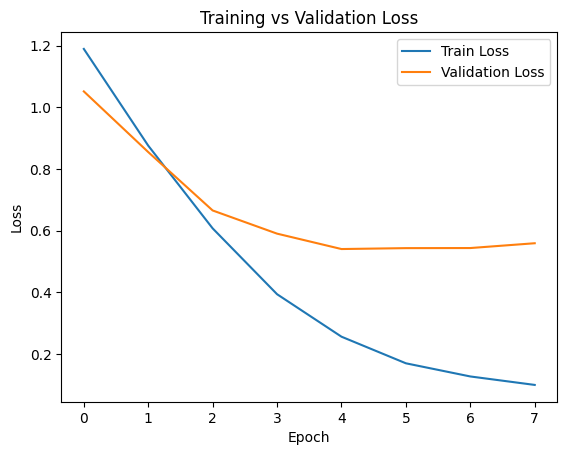

In [248]:
plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()